In [1]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Ch_G.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }



===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873
1  0.001  0.3454
2  0.002  0.4057
3  0.003  0.4267
4  0.004  0.4324

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.238220  0.542358  0.726257  0.348633
1  0.004  0.238228  0.542376  0.726250  0.348674
2  0.008  0.238227  0.542373  0.726216  0.348764
3  0.012  0.238227  0.542344  0.726188  0.348857
4  0.016  0.238259  0.542317  0.726161  0.348920

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.526794 -0.283691 -0.028687  0.800720
1  0.004 -0.526864 -0.283604 -0.028748  0.800703
2  0.008 -0.526988 -0.283423 -0.028840  0.800676
3  0.012 -0.527083 -0.283302 -0.028870  0.800649
4  0.016 -0.527146 -0.283242 -0.028871  0.800623

Baseline wrist: [0.322, 0.519, 0.689, 0.39]
Baseline shoulder: [-0.515, -0.288, -0.043, 0.806]

Shapes: (47023, 2) (11751, 5) (11751, 5)


In [4]:
# ==========================================================
# STEP 2: QUATERNION -> ANGLE X (avec baseline)
# ==========================================================
import numpy as np

def normalize_quaternion(q):
    q = np.array(q, dtype=float)
    return q / np.linalg.norm(q)

def quat_conjugate(q):
    return np.array([-q[0], -q[1], -q[2], q[3]])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def quaternion_to_angle_x(df_quat, baseline):
    baseline = normalize_quaternion(baseline)
    baseline_inv = quat_conjugate(baseline)

    angles = []

    for _, row in df_quat.iterrows():
        q = normalize_quaternion([row.qx, row.qy, row.qz, row.qw])

        # correction baseline
        q_corr = quat_multiply(baseline_inv, q)

        x, y, z, w = q_corr

        angle_x = np.arctan2(
            2*(w*x + y*z),
            1 - 2*(x*x + y*y)
        )

        angles.append(np.degrees(angle_x))

    df_out = df_quat.copy()
    df_out["angle_x"] = angles

    return df_out


# ==========================================================
# STEP 3: CALCUL DES ANGLES
# ==========================================================
df_wrist_angle = quaternion_to_angle_x(df_wrist, baseline["wrist"])
df_shoulder_angle = quaternion_to_angle_x(df_shoulder, baseline["shoulder"])

In [6]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(signal, cutoff, fs, order=4):

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')

    return filtfilt(b, a, signal)


# fréquence capteur
fs_move = 250  

df_wrist_angle["angle_x_filt"] = butter_lowpass_filter(
    df_wrist_angle["angle_x"],
    cutoff=10,
    fs=fs_move
)

df_shoulder_angle["angle_x_filt"] = butter_lowpass_filter(
    df_shoulder_angle["angle_x"],
    cutoff=10,
    fs=fs_move
)

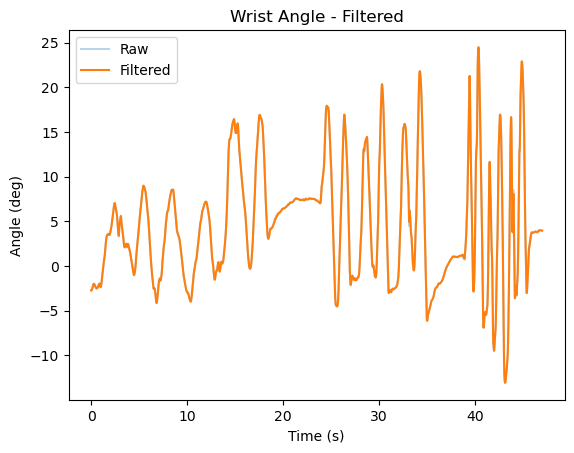

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df_wrist_angle["time"], df_wrist_angle["angle_x"], alpha=0.3, label="Raw")
plt.plot(df_wrist_angle["time"], df_wrist_angle["angle_x_filt"], label="Filtered")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Wrist Angle - Filtered")
plt.legend()
plt.show()

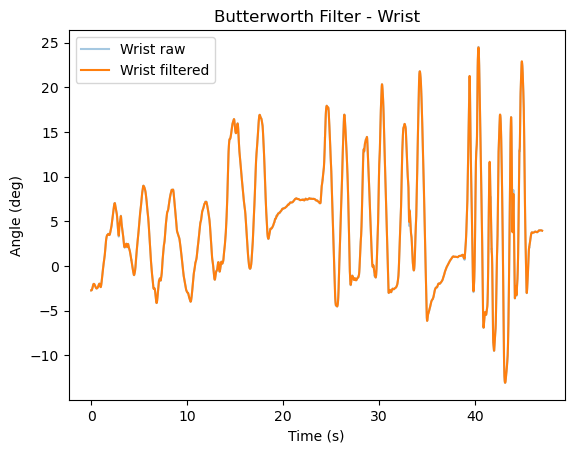

In [9]:
from scipy.signal import butter, filtfilt

# ==========================================================
# BUTTERWORTH LOW-PASS FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """
    Apply a low-pass Butterworth filter

    Parameters:
        signal (array): signal to filter
        cutoff (float): cutoff frequency (Hz)
        fs (float): sampling frequency (Hz)
        order (int): filter order

    Returns:
        filtered signal
    """

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    filtered = filtfilt(b, a, signal)

    return filtered

# Fréquence K-Move
fs_move = 250  

# Filtrage
df_wrist_angle["angle_x_filt"] = butter_lowpass_filter(
    df_wrist_angle["angle_x"],
    cutoff=10,
    fs=fs_move
)

df_shoulder_angle["angle_x_filt"] = butter_lowpass_filter(
    df_shoulder_angle["angle_x"],
    cutoff=10,
    fs=fs_move
)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(df_wrist_angle["time"], df_wrist_angle["angle_x"], alpha=0.4, label="Wrist raw")
plt.plot(df_wrist_angle["time"], df_wrist_angle["angle_x_filt"], label="Wrist filtered")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Butterworth Filter - Wrist")
plt.legend()
plt.show()